---
title: "FIFA World Cup 2026 Predictor"
subtitle: "A live experiment: predicting every round of the tournament, in public, as it happens"
author: "Miguel R."
date: today
categories: [Machine Learning]
description: "One Poisson model per national team, predicting every round of the 2026 World Cup while the tournament is being played."
---

## A live experiment

Most prediction projects are published after the fact, when it is easy to look smart.
This one runs the other way around: **before each round of the 2026 World Cup, the model
publishes its predictions, and after the round we score them against reality** — no
retroactive edits, no cherry-picking.

> **Status: tournament in progress.** Group stage and Round of 32 are complete and
> scored. The Round of 16 is being played right now, and this page updates after every
> round until the final on July 19.

The scoreboard and the bracket below are generated straight from the prediction files
and the match results, so what you see is exactly what the model committed to.


## Why not just compare Elo ratings?

[Elo ratings](https://eloratings.net) are the obvious starting point for international
football: a single number per team, updated after every match. But predicting a winner
by comparing two Elo numbers has a built-in flaw: **it always picks the higher-rated
team.** It can never see an upset coming, it says nothing about the score, and it treats
a 5-goal thrashing and a penalty-shootout escape as the same outcome.

The Elo rating is a *snapshot* of how strong a team is today. What it does not capture
is *behavior*: how many goals a team tends to score against opposition of a given
strength, in a given place, in a given kind of match. That behavior is what this project
models.


## The model: one Poisson regression per team

Instead of one global model, we train **a separate Poisson regression for every national
team**, on that team's own match history. The target is the number of goals the team
scores in a match, and the features are:

- **Opponent strength** — the opponent's Elo rating going into the match (and the team's
  own rating, both scaled).
- **Location** — where the match is played. This matters twice in 2026: home advantage in
  general, and the fact that the hosts (United States, Mexico, Canada) play the entire
  tournament on home soil. The model learns how well Mexico plays in Mexico, and also how
  well Paraguay plays in Mexico.
- **Match type** — friendlies, official competitions and World Cup matches are different
  animals; teams that stroll through friendlies can collapse under tournament pressure.
- **Recency** — matches are weighted with an exponential time decay (half-life of two
  years), so the model cares much more about the current squad's form than about a
  golden generation from a decade ago.

To predict a match, we ask each team's model the same question: *how many goals would you
score against this opponent, here, in a World Cup match?* The two answers give a
predicted score, and the higher answer picks the winner.

Training on each team's own history also preserves identity. Playing Brazil has a weight
of its own that a rating number does not fully capture, and a per-team model keeps
those matchup dynamics in the data it learns from.


## The player layer: an ensemble on top

Team-level history says nothing about *who is actually on the pitch*. So a second
workflow adds a player layer: using individual player Elo ratings, we compare the
average of a team's **four best attackers** against the opponent's **defensive block**
(four best defenders, best midfielder and best goalkeeper). That attack-versus-defense
ratio, raised to a damping exponent tuned on the completed rounds
(`(atk/def) ** 2.5` - the experiment lives on the
[model vs reality](compare_results.ipynb) page), scales the predicted goals up or down.

Both workflows predict the same fixtures from the same data, which turns the tournament
into a controlled comparison: [naive](rounds_naive.ipynb) (team history only) versus
[ensemble](rounds_ensemble.ipynb) (team history plus players). Whether the player layer
actually earns its keep is tracked on the [model vs reality](compare_results.ipynb) page.


## The favorites, by Elo

Before any modeling, the ratings themselves sketch the landscape: the eight strongest
teams entering the tournament, and how they got here since the 2018 cycle.


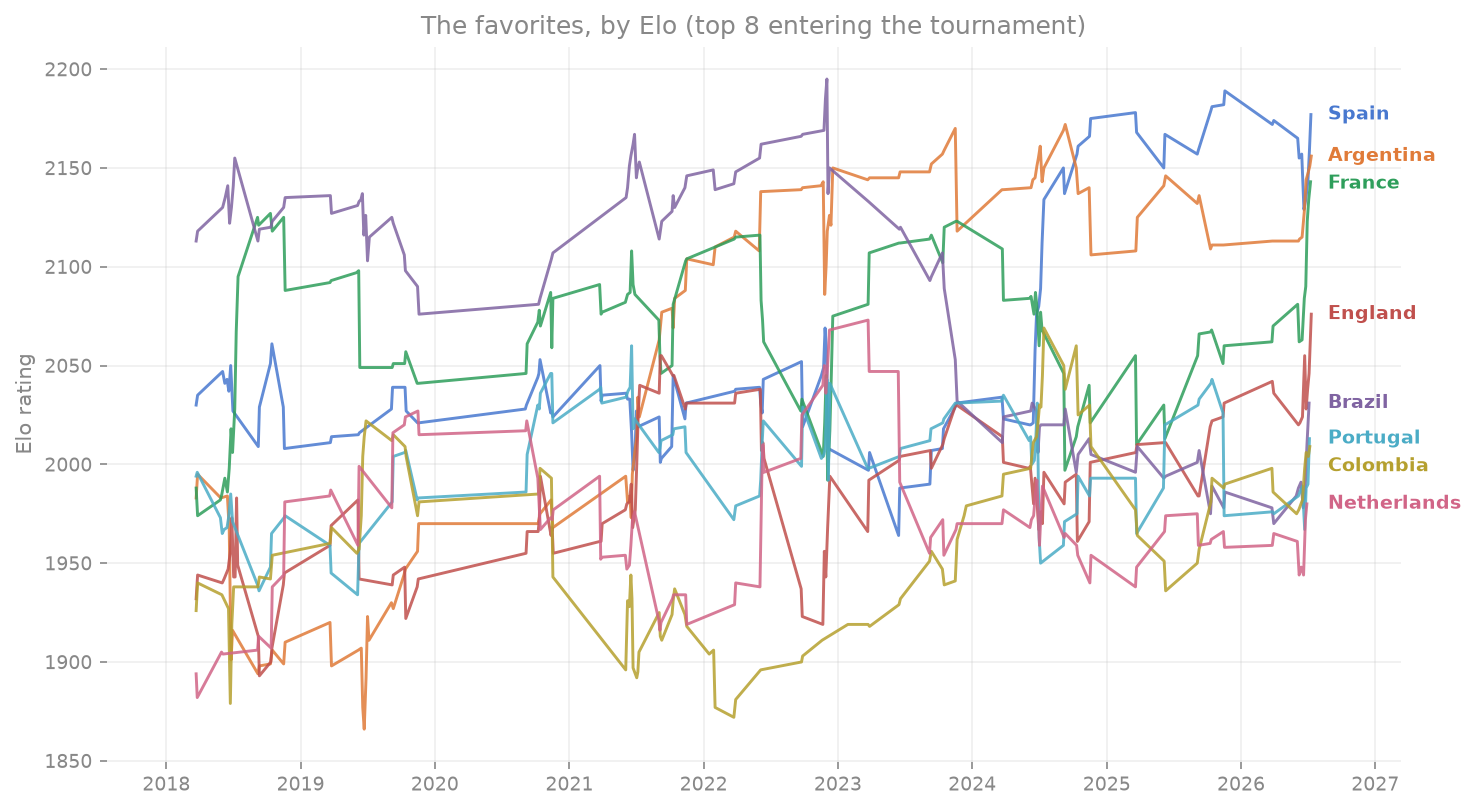

In [1]:
from report_utils import plot_elo_landscape

fig = plot_elo_landscape()

## Scoreboard

Winner accuracy and mean absolute goal error per round, for both workflows, over every
match played so far. A real draw always counts as a miss: a Poisson model practically
never predicts identical expected goals for both sides.


In [2]:
from report_utils import scoreboard

scoreboard()

,round,matches,naive_accuracy,naive_goal_mae,ensemble_accuracy,ensemble_goal_mae
0,Group stage - Matchday 1,24,0.500,2.14,0.542,2.59
1,Group stage - Matchday 2,24,0.458,1.62,0.625,1.75
2,Group stage - Matchday 3,24,0.458,1.83,0.542,1.86
3,Round of 32,16,0.625,1.51,0.688,1.68
4,Round of 16,8,0.625,1.19,0.750,1.08
5,Quarter-finals,4,0.750,0.83,1.000,0.87


## The bracket: predictions vs reality

The knockout stage, as the model called it and as it actually happened. Bold marks the
model's pick: green when the pick advanced, red when it was eliminated. Green shading
follows the team that actually went through, and dashed slots are rounds not yet drawn.


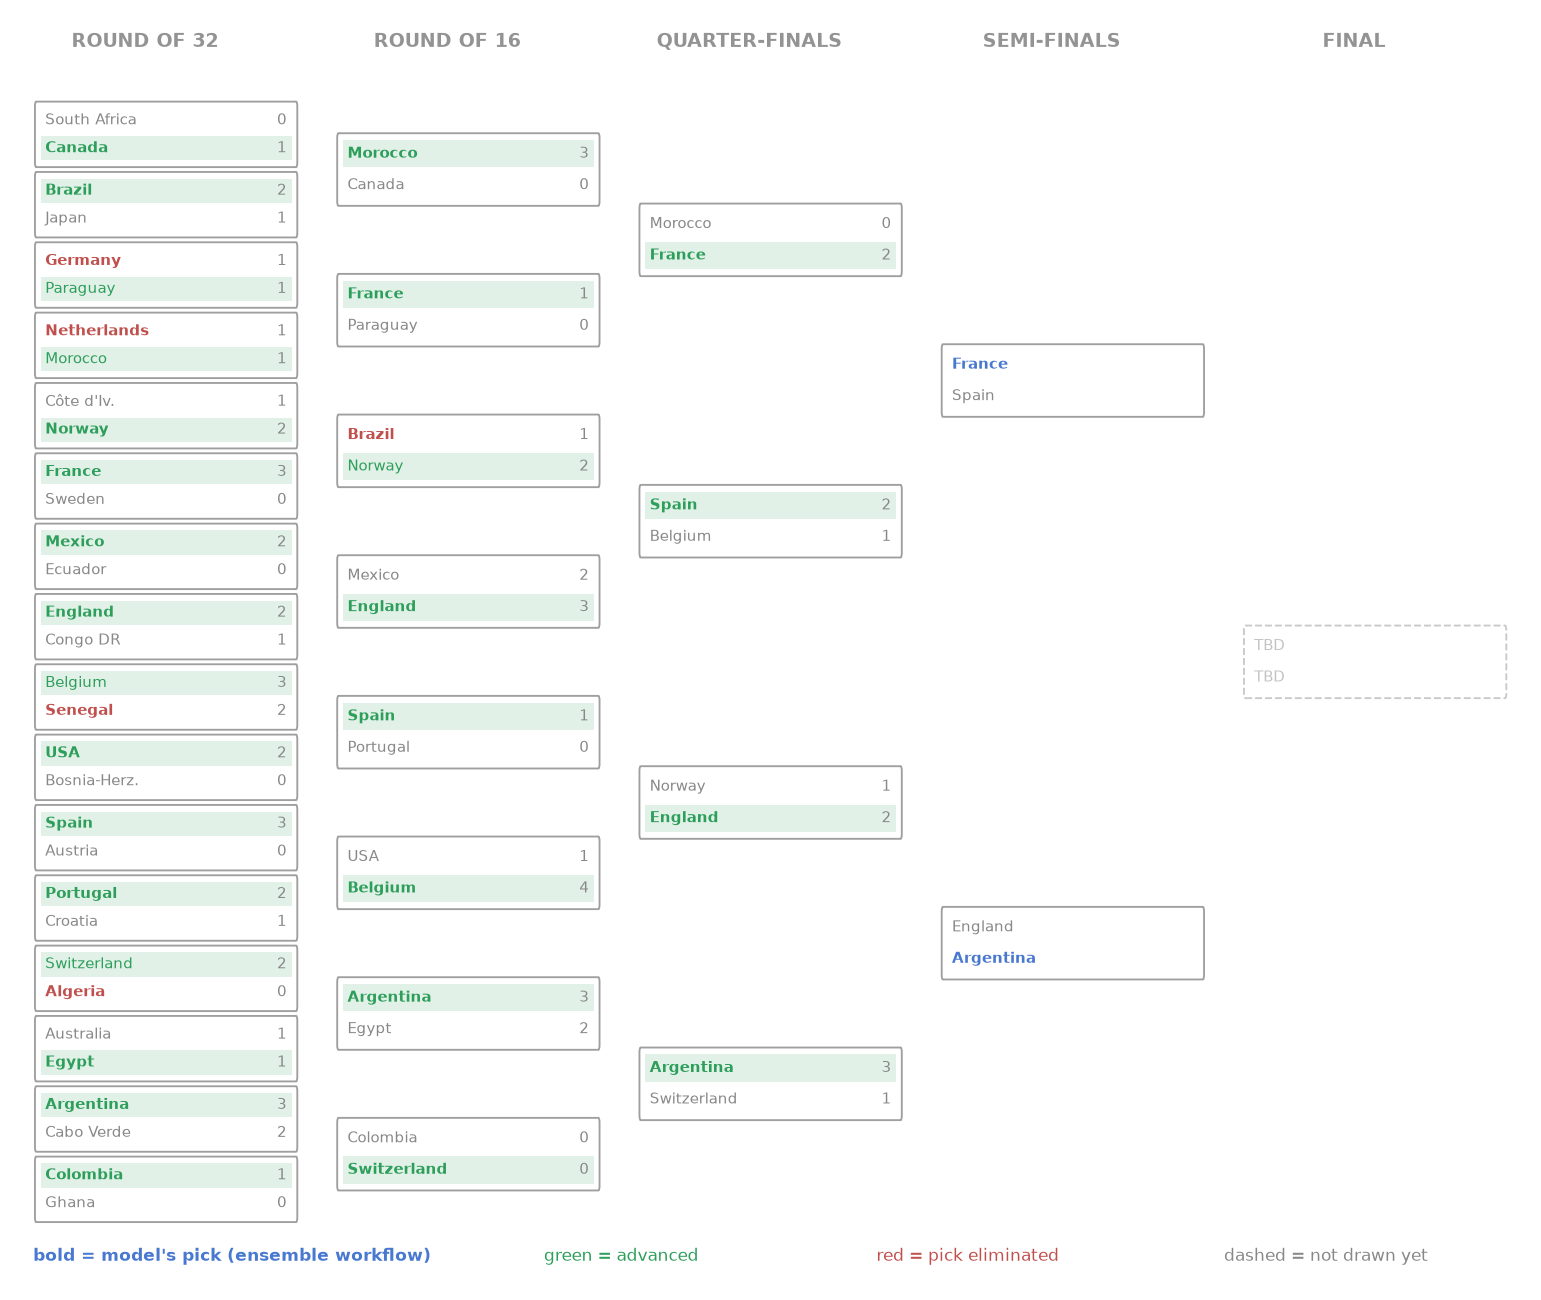

In [3]:
from report_utils import plot_bracket

fig = plot_bracket(prefix="ensemble")

## Honest limitations

- **Draws and penalties.** The model predicts expected goals, not shootouts. Knockout
  matches that finish level are recorded as draws in the match history, so the model is
  penalized even when its pick advanced on penalties.
- **Squad reality.** Injuries, suspensions and rotation are invisible to both workflows.
- **Small windows.** A World Cup is 104 matches. Accuracy numbers per round move a lot
  with two or three results, so treat the round-by-round scoreboard as a trajectory, not
  a verdict.
